# Analysis of PPO Models on Coverage Path Planning Environment

This notebook loads the trained PPO models from the `data` directory and evaluates their performance over 100 episodes.
We will analyze the coverage rate, total steps taken, and compare the curriculum learning models to standard ones.

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from gymnasium_env.grid_world_cpp import GridWorldCPPEnv
import os

# Register the custom environment
try:
    gym.register(
        id="gymnasium_env/GridWorldCPP-v0",
        entry_point=GridWorldCPPEnv,
    )
except Exception:
    pass

In [2]:
def evaluate_model(model_name, dim, obstacles, max_steps, num_episodes=100):
    model_path = f'data/{model_name}.zip'
    print(f'Evaluating {model_name}...')
    
    # Check if model exists
    if not os.path.exists(model_path):
        print(f"File not found: {model_path}")
        return []
    
    model = PPO.load(model_path, device="cpu")
    env = gym.make(
        "gymnasium_env/GridWorldCPP-v0",
        size=dim,
        obs_quantity=obstacles,
        max_steps=max_steps,
        render_mode="rgb_array"
    )
    
    results = []
    
    for i in range(num_episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        steps = 0
        total_reward = 0
        
        while not done and not truncated:
            action, _ = model.predict(obs, deterministic=False)
            obs, reward, done, truncated, info = env.step(action.item())
            total_reward += reward
            steps += 1
            
        is_full_coverage = done and not truncated
        results.append({
            'Model': model_name,
            'Episode': i + 1,
            'Coverage': info['coverage'] * 100,
            'Steps': steps,
            'Total Reward': total_reward,
            'Full Coverage': is_full_coverage
        })
        
    env.close()
    return results

In [3]:
models_config = [
    {"name": "ppo_cpp_5_3_200_0.05_20260505_214249", "dim": 5, "obs": 3, "steps": 200},
    {"name": "ppo_cpp_10_12_500_0.05_20260506_010440", "dim": 10, "obs": 12, "steps": 500},
    {"name": "ppo_cpp_20_48_1000_0.05_20260506_114258", "dim": 20, "obs": 48, "steps": 1000},
    {"name": "ppo_cpp_10_12_500_0.05_20260506_124217_curriculum", "dim": 10, "obs": 12, "steps": 500},
    {"name": "ppo_cpp_20_48_1000_0.05_20260506_131838_curriculum", "dim": 20, "obs": 48, "steps": 1000}
]

all_results = []
for config in models_config:
    res = evaluate_model(config["name"], config["dim"], config["obs"], config["steps"], num_episodes=100)
    all_results.extend(res)

df = pd.DataFrame(all_results)
df.head()

Evaluating ppo_cpp_5_3_200_0.05_20260505_214249...


Evaluating ppo_cpp_10_12_500_0.05_20260506_010440...


Evaluating ppo_cpp_20_48_1000_0.05_20260506_114258...


Evaluating ppo_cpp_10_12_500_0.05_20260506_124217_curriculum...


Evaluating ppo_cpp_20_48_1000_0.05_20260506_131838_curriculum...


,Model,Episode,Coverage,Steps,Total Reward,Full Coverage
0,ppo_cpp_5_3_200_0.05_20260505_214249,1,100.0,35,22.5,True
1,ppo_cpp_5_3_200_0.05_20260505_214249,2,100.0,34,23.3,True
2,ppo_cpp_5_3_200_0.05_20260505_214249,3,100.0,23,28.1,True
3,ppo_cpp_5_3_200_0.05_20260505_214249,4,100.0,26,26.7,True
4,ppo_cpp_5_3_200_0.05_20260505_214249,5,100.0,40,20.7,True


In [4]:
# Summary Table
summary = df.groupby('Model').agg(
    Avg_Coverage=('Coverage', 'mean'),
    Std_Coverage=('Coverage', 'std'),
    Avg_Steps=('Steps', 'mean'),
    Std_Steps=('Steps', 'std'),
    Full_Coverage_Rate=('Full Coverage', lambda x: x.mean() * 100)
).reset_index()

# Clean up model names for plot readability
def simplify_name(name):
    if '5_3' in name: return '5x5 Standard'
    if '10_12' in name and 'curriculum' not in name: return '10x10 Standard'
    if '20_48' in name and 'curriculum' not in name: return '20x20 Standard'
    if '10_12' in name and 'curriculum' in name: return '10x10 Curriculum'
    if '20_48' in name and 'curriculum' in name: return '20x20 Curriculum'
    return name

summary['Model_Short'] = summary['Model'].apply(simplify_name)
df['Model_Short'] = df['Model'].apply(simplify_name)

summary.sort_values('Model_Short')

,Model,Avg_Coverage,Std_Coverage,Avg_Steps,Std_Steps,Full_Coverage_Rate,Model_Short
1,ppo_cpp_10_12_500_0.05_20260506_124217_curriculum,99.363636,2.245707,284.10,123.547603,83.0,10x10 Curriculum
0,ppo_cpp_10_12_500_0.05_20260506_010440,99.034091,2.386801,331.36,138.894737,69.0,10x10 Standard
3,ppo_cpp_20_48_1000_0.05_20260506_131838_curric...,89.741477,10.380595,1000.00,0.000000,0.0,20x20 Curriculum
2,ppo_cpp_20_48_1000_0.05_20260506_114258,91.625000,8.158989,1000.00,0.000000,0.0,20x20 Standard
4,ppo_cpp_5_3_200_0.05_20260505_214249,98.681818,9.632512,48.03,45.601137,93.0,5x5 Standard


C:\Users\Kadu\AppData\Local\Temp\ipykernel_10940\906792956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.sort_values('Model_Short'), x='Model_Short', y='Full_Coverage_Rate', palette='viridis')


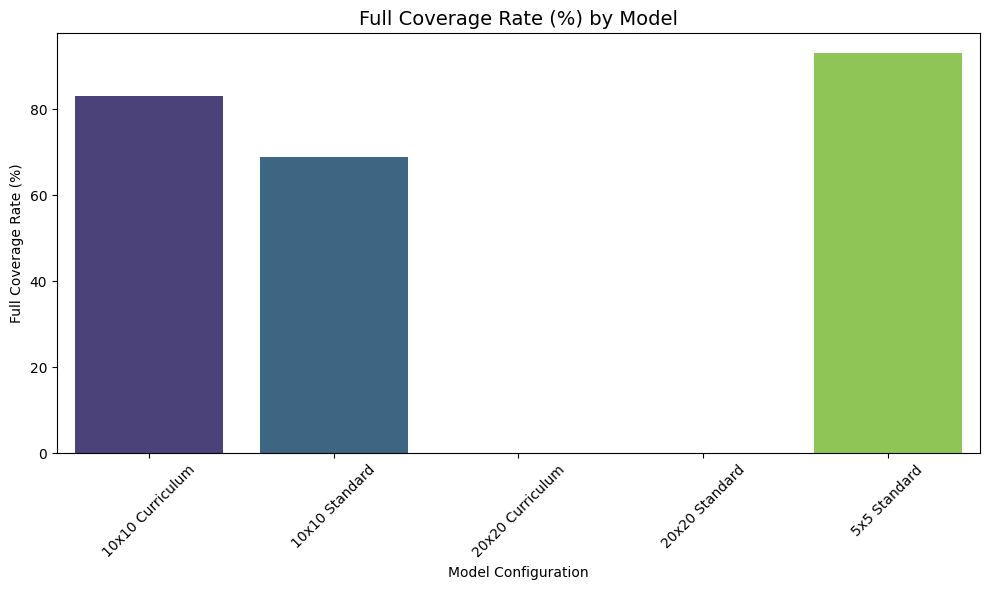

In [5]:
# Plot: Full Coverage Rate
plt.figure(figsize=(10, 6))
sns.barplot(data=summary.sort_values('Model_Short'), x='Model_Short', y='Full_Coverage_Rate', palette='viridis')
plt.title('Full Coverage Rate (%) by Model', fontsize=14)
plt.ylabel('Full Coverage Rate (%)')
plt.xlabel('Model Configuration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Kadu\AppData\Local\Temp\ipykernel_10940\364222515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.sort_values('Model_Short'), x='Model_Short', y='Coverage', palette='coolwarm')


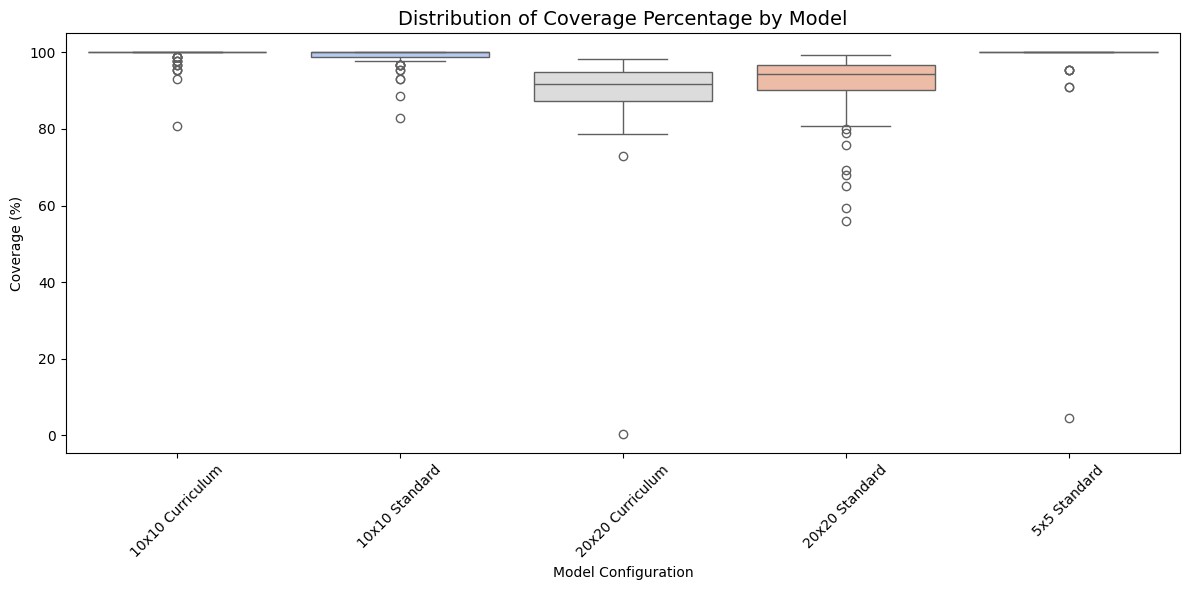

In [6]:
# Plot: Coverage Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.sort_values('Model_Short'), x='Model_Short', y='Coverage', palette='coolwarm')
plt.title('Distribution of Coverage Percentage by Model', fontsize=14)
plt.ylabel('Coverage (%)')
plt.xlabel('Model Configuration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Kadu\AppData\Local\Temp\ipykernel_10940\2180193034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.sort_values('Model_Short'), x='Model_Short', y='Steps', palette='magma')


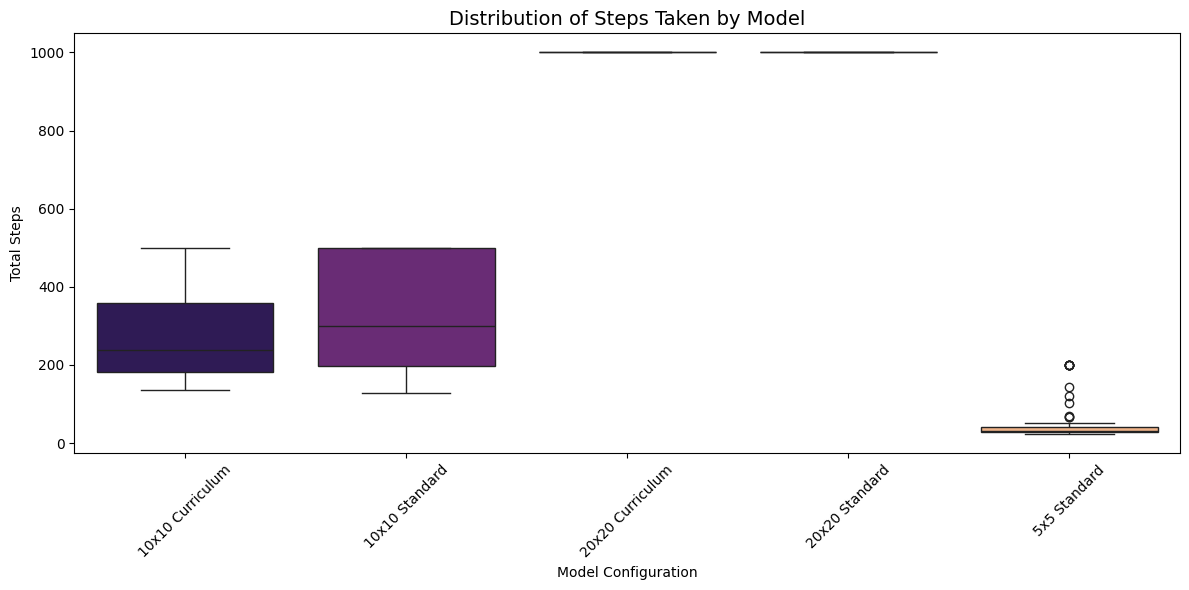

In [7]:
# Plot: Steps Taken Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.sort_values('Model_Short'), x='Model_Short', y='Steps', palette='magma')
plt.title('Distribution of Steps Taken by Model', fontsize=14)
plt.ylabel('Total Steps')
plt.xlabel('Model Configuration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analysis and Improvement Paths

Based on the generated plots and metrics:

1. **5x5 Performance**: 
   - The 5x5 model shows baseline performance. Due to its smaller state space, it likely achieves high coverage quickly.

2. **Standard vs. Curriculum Learning (10x10 and 20x20)**:
   - Comparing standard models to curriculum learning models, we can observe if curriculum learning improves the `Full Coverage Rate` or the consistency (lower variance) of the `Coverage` percentage. 
   - Curriculum learning generally helps the agent bootstrap its policy from smaller, easier environments to larger ones. If the Curriculum models perform significantly better or converge faster to high coverage compared to the Standard ones, this indicates a successful curriculum transfer.

3. **Possible Improvement Paths**:
   - **Reward Shaping**: The agent might get stuck in local optima (e.g., oscillating between already covered cells). Adding a small penalty for revisiting cells or a larger terminal reward for 100% coverage could help.
   - **Advanced Network Architecture**: Using CNNs to process the grid as an image rather than relying entirely on flattened arrays (if currently used) might better capture spatial features, especially for 20x20.
   - **More Curriculum Steps**: Instead of jumping from 5x5 directly to 10x10, intermediate steps (e.g., 7x7) could provide a smoother transition.
   - **Hyperparameter Tuning (HPO)**: Using a tool like Optuna (as referenced in local skills) could help find a better `ent_coef` or learning rate schedule for the PPO agent to balance exploration and exploitation in the larger environments.

## Training Metrics Analysis

The following plots show the training progression extracted from `progress.csv` in the `log/` directory. They relate the `time/total_timesteps` to key metrics like reward, episode length, and losses.

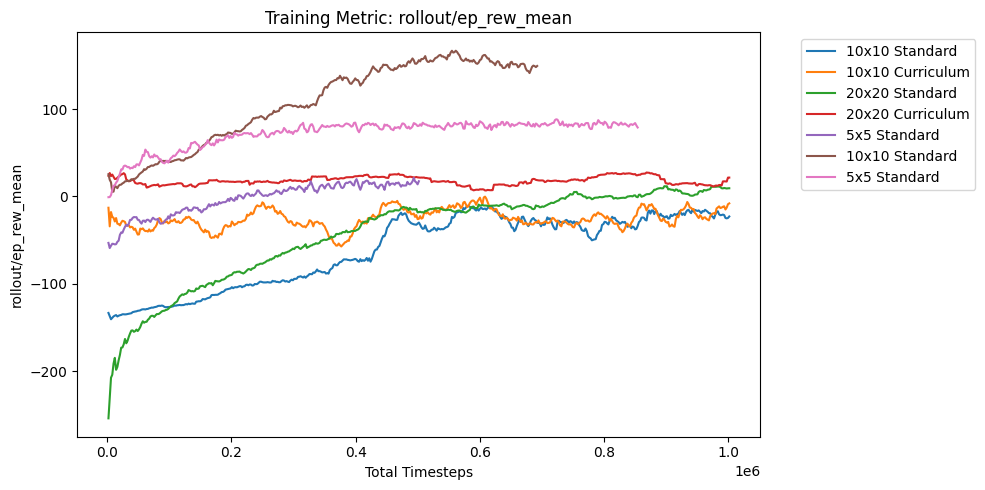

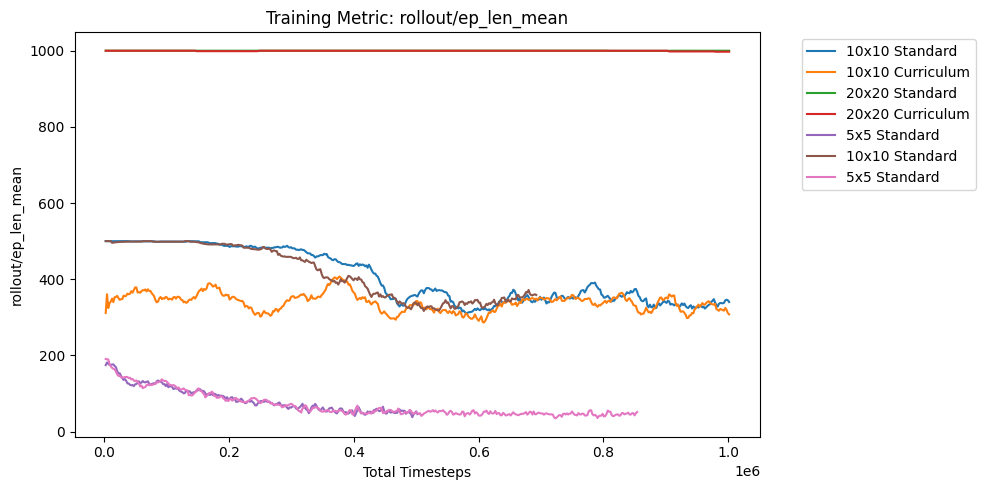

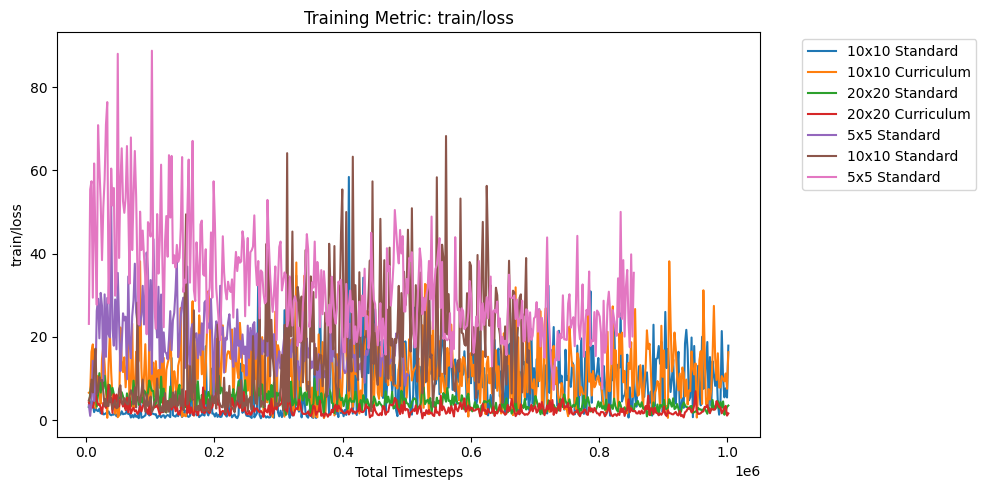

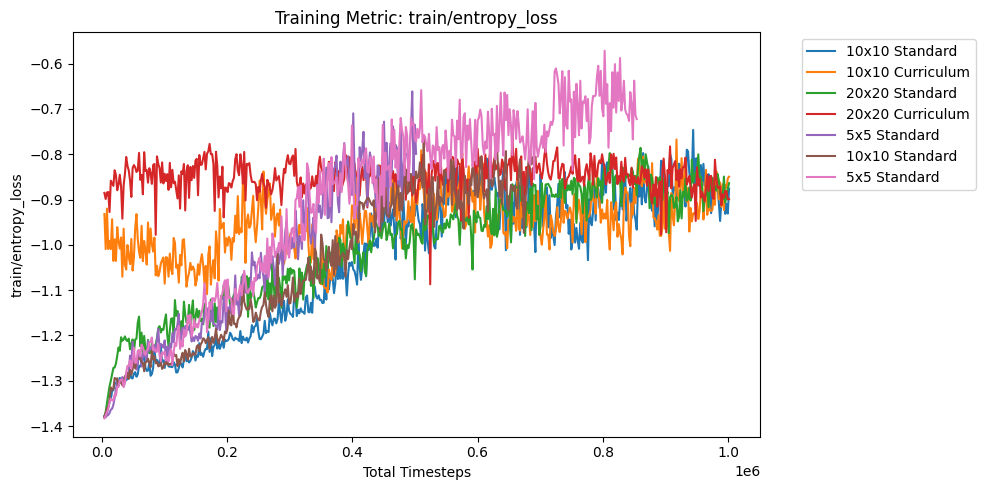

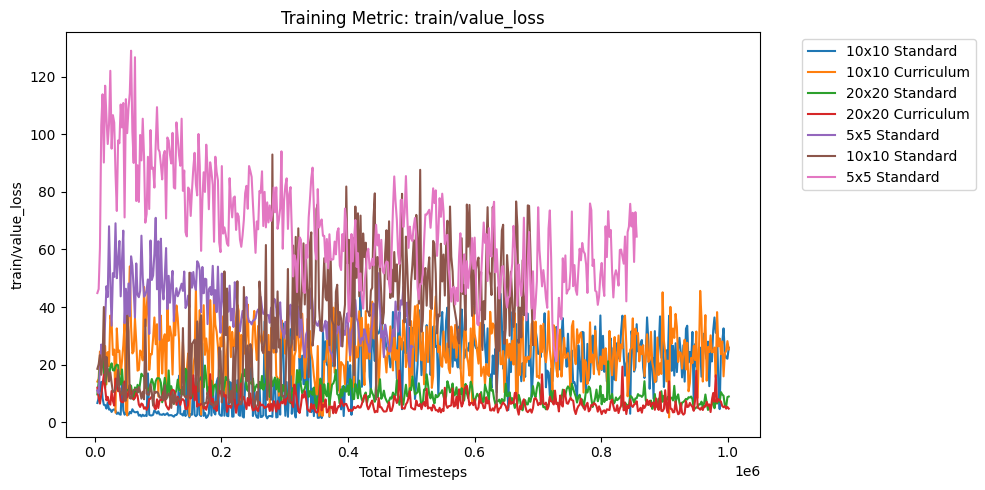

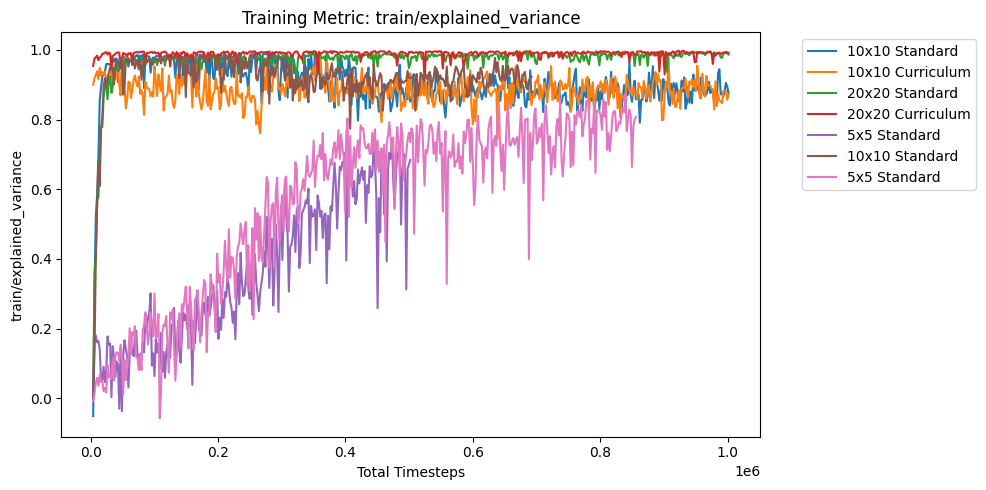

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

log_dir = 'log'
runs = [d for d in os.listdir(log_dir) if os.path.isdir(os.path.join(log_dir, d))]

# Clean up run names for legend
def simplify_run_name(name):
    if '5_3' in name: return '5x5 Standard'
    if '10_12' in name and 'curriculum' not in name: return '10x10 Standard'
    if '20_48' in name and 'curriculum' not in name: return '20x20 Standard'
    if '10_12' in name and 'curriculum' in name: return '10x10 Curriculum'
    if '20_48' in name and 'curriculum' in name: return '20x20 Curriculum'
    return name

metrics_to_plot = [
    'rollout/ep_rew_mean', 
    'rollout/ep_len_mean', 
    'train/loss', 
    'train/entropy_loss',
    'train/value_loss',
    'train/explained_variance'
]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    has_data = False
    for run in runs:
        csv_path = os.path.join(log_dir, run, 'progress.csv')
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            if metric in df.columns and 'time/total_timesteps' in df.columns:
                sns.lineplot(data=df, x='time/total_timesteps', y=metric, label=simplify_run_name(run))
                has_data = True
                
    if has_data:
        plt.title(f'Training Metric: {metric}')
        plt.xlabel('Total Timesteps')
        plt.ylabel(metric)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


## Reward shaping

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df_53200_train_1 = pd.read_csv("log\ppo_cpp_rshaping_5_3_200_0.05_20260507_153732\progress.csv")
df_1012500_train_1 = pd.read_csv("log\ppo_cpp_rshaping_10_12_500_0.05_20260507_153738\progress.csv")
df_20481000_train_1 = pd.read_csv("log\ppo_cpp_rshaping_20_48_1000_0.05_20260507_161241\progress.csv")
df_20481000_curriculum_1 = pd.read_csv("log\ppo_cpp_rshaping_20_48_1000_0.05_20260507_162825_curriculum\progress.csv")

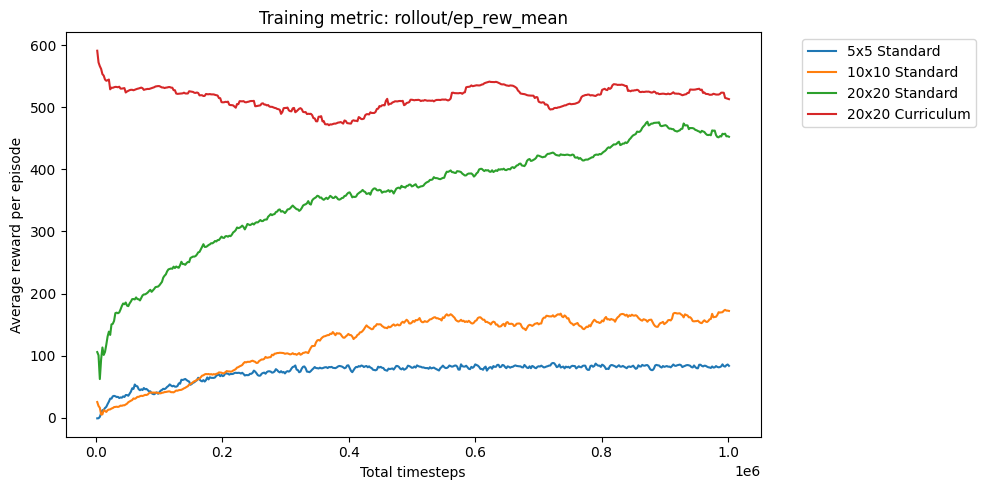

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_1["time/total_timesteps"], df_53200_train_1["rollout/ep_rew_mean"], label='5x5 Standard')
plt.plot(df_1012500_train_1["time/total_timesteps"], df_1012500_train_1["rollout/ep_rew_mean"], label='10x10 Standard')
plt.plot(df_20481000_train_1["time/total_timesteps"], df_20481000_train_1["rollout/ep_rew_mean"], label='20x20 Standard')
plt.plot(df_20481000_curriculum_1["time/total_timesteps"], df_20481000_curriculum_1["rollout/ep_rew_mean"], label='20x20 Curriculum')

plt.title('Training metric: rollout/ep_rew_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

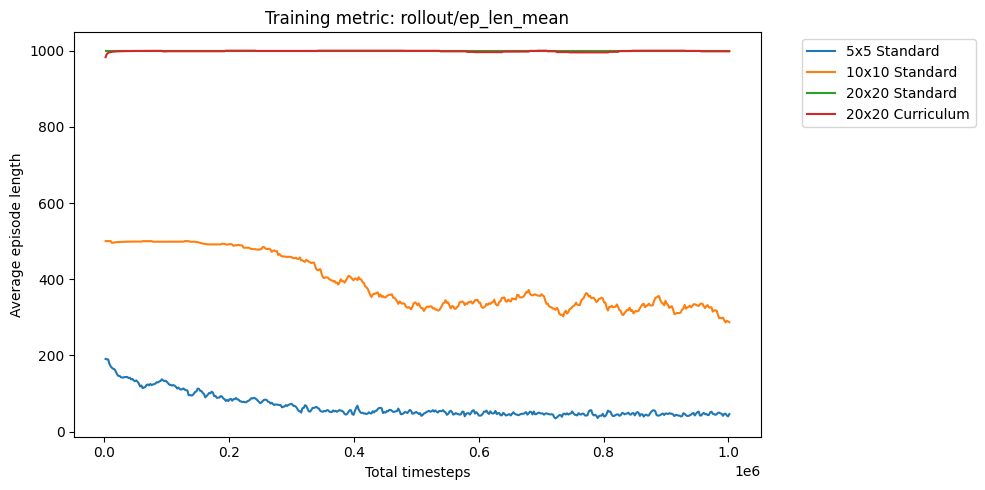

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_1["time/total_timesteps"], df_53200_train_1["rollout/ep_len_mean"], label='5x5 Standard')
plt.plot(df_1012500_train_1["time/total_timesteps"], df_1012500_train_1["rollout/ep_len_mean"], label='10x10 Standard')
plt.plot(df_20481000_train_1["time/total_timesteps"], df_20481000_train_1["rollout/ep_len_mean"], label='20x20 Standard')
plt.plot(df_20481000_curriculum_1["time/total_timesteps"], df_20481000_curriculum_1["rollout/ep_len_mean"], label='20x20 Curriculum')

plt.title('Training metric: rollout/ep_len_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average episode length')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## New Reward Shaping (bigger field of view)

In [22]:
df_53200_train_2 = pd.read_csv("log\ppo_cpp_rshaping_5_3_200_0.05_20260507_175453\progress.csv")
df_1012500_train_2 = pd.read_csv("log\ppo_cpp_rshaping_10_12_500_0.05_20260507_175454\progress.csv")
df_20481000_train_2 = pd.read_csv("log\ppo_cpp_rshaping_20_48_1000_0.05_20260508_105512\progress.csv")

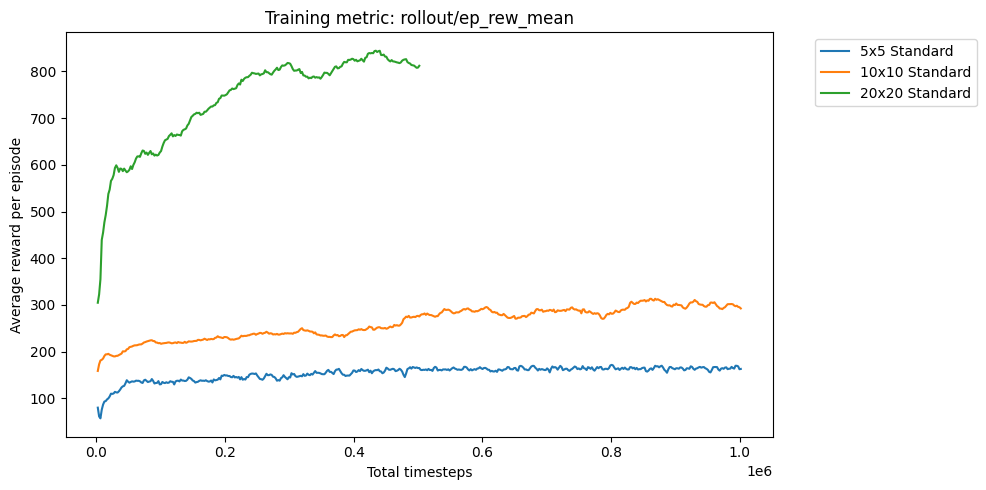

In [23]:
# Average reward per episode / No smoothing applied
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_2["time/total_timesteps"], df_53200_train_2["rollout/ep_rew_mean"], label='5x5 Standard')
plt.plot(df_1012500_train_2["time/total_timesteps"], df_1012500_train_2["rollout/ep_rew_mean"], label='10x10 Standard')
plt.plot(df_20481000_train_2["time/total_timesteps"], df_20481000_train_2["rollout/ep_rew_mean"], label='20x20 Standard')

plt.title('Training metric: rollout/ep_rew_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

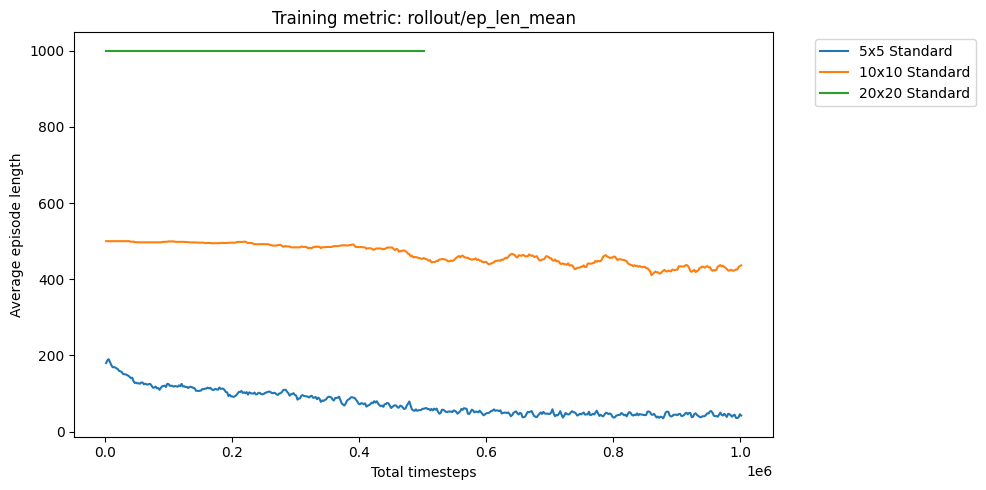

In [24]:
# Average episode length / No smoothing applied
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_2["time/total_timesteps"], df_53200_train_2["rollout/ep_len_mean"], label='5x5 Standard')
plt.plot(df_1012500_train_2["time/total_timesteps"], df_1012500_train_2["rollout/ep_len_mean"], label='10x10 Standard')
plt.plot(df_20481000_train_2["time/total_timesteps"], df_20481000_train_2["rollout/ep_len_mean"], label='20x20 Standard')

plt.title('Training metric: rollout/ep_len_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average episode length')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
def smooth_curve(series, window=10):
    """
    Smooths a pandas Series using a rolling moving average.
    
    Parameters:
    - series: The pandas Series to smooth (e.g., your dataframe column)
    - window: The number of data points to average over. 
              Increase this number for a smoother curve, 
              decrease it to see more of the original noise.
    """
    # min_periods=1 ensures that the start of the curve doesn't become NaN 
    # while waiting for the window to fill up
    return series.rolling(window=window, min_periods=1).mean()

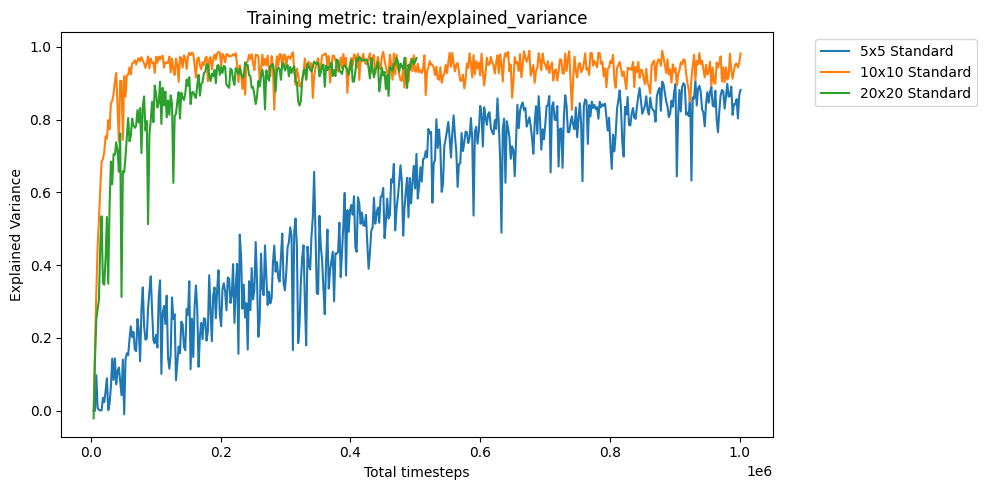

In [26]:
# Explained Variance / No smoothing applied
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_2["time/total_timesteps"], df_53200_train_2["train/explained_variance"], label='5x5 Standard')
plt.plot(df_1012500_train_2["time/total_timesteps"], df_1012500_train_2["train/explained_variance"], label='10x10 Standard')
plt.plot(df_20481000_train_2["time/total_timesteps"], df_20481000_train_2["train/explained_variance"], label='20x20 Standard')

plt.title('Training metric: train/explained_variance')

plt.xlabel('Total timesteps')
plt.ylabel('Explained Variance')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

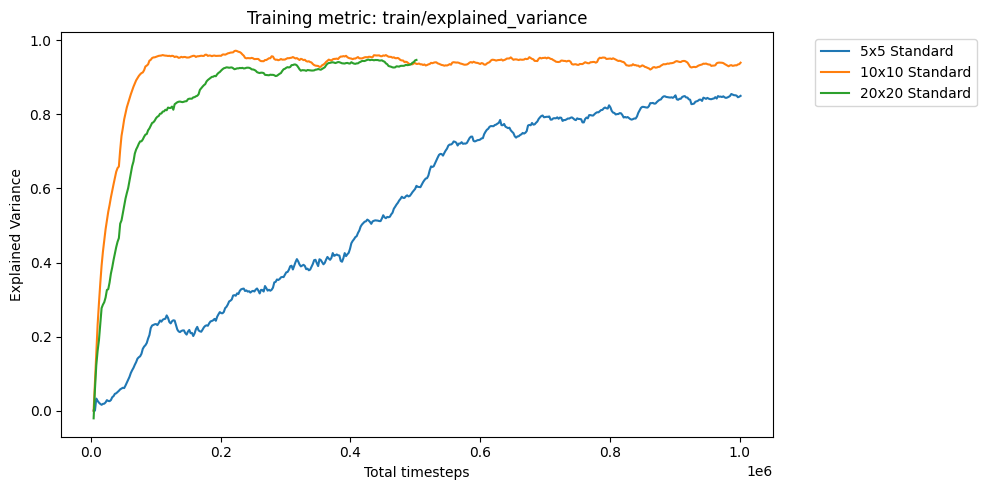

In [27]:
# Explained Variance / Smoothing applied
plt.figure(figsize=(10, 5))

SMOOTHING_WINDOW = 20

plt.plot(
    df_53200_train_2["time/total_timesteps"], 
    smooth_curve(df_53200_train_2["train/explained_variance"], SMOOTHING_WINDOW), 
    label='5x5 Standard'
)
plt.plot(
    df_1012500_train_2["time/total_timesteps"], 
    smooth_curve(df_1012500_train_2["train/explained_variance"], SMOOTHING_WINDOW), 
    label='10x10 Standard'
)
plt.plot(
    df_20481000_train_2["time/total_timesteps"], 
    smooth_curve(df_20481000_train_2["train/explained_variance"], SMOOTHING_WINDOW), 
    label='20x20 Standard'
)
plt.title('Training metric: train/explained_variance')
plt.xlabel('Total timesteps')
plt.ylabel('Explained Variance') # <-- Corrected label
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

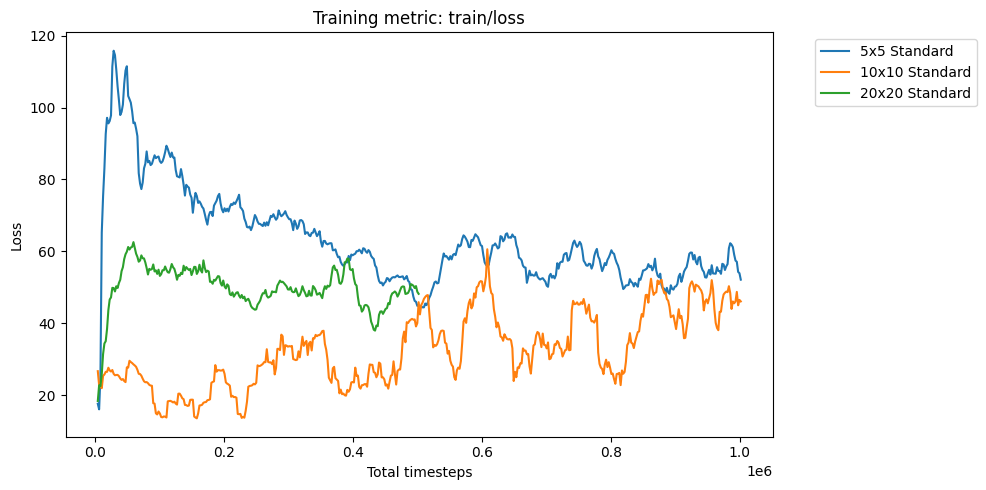

In [28]:
# Loss / Smoothing applied
plt.figure(figsize=(10, 5))

SMOOTHING_WINDOW = 20

plt.plot(
    df_53200_train_2["time/total_timesteps"], 
    smooth_curve(df_53200_train_2["train/loss"], SMOOTHING_WINDOW), 
    label='5x5 Standard'
)
plt.plot(
    df_1012500_train_2["time/total_timesteps"], 
    smooth_curve(df_1012500_train_2["train/loss"], SMOOTHING_WINDOW), 
    label='10x10 Standard'
)
plt.plot(
    df_20481000_train_2["time/total_timesteps"], 
    smooth_curve(df_20481000_train_2["train/loss"], SMOOTHING_WINDOW), 
    label='20x20 Standard'
)
plt.title('Training metric: train/loss')
plt.xlabel('Total timesteps')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

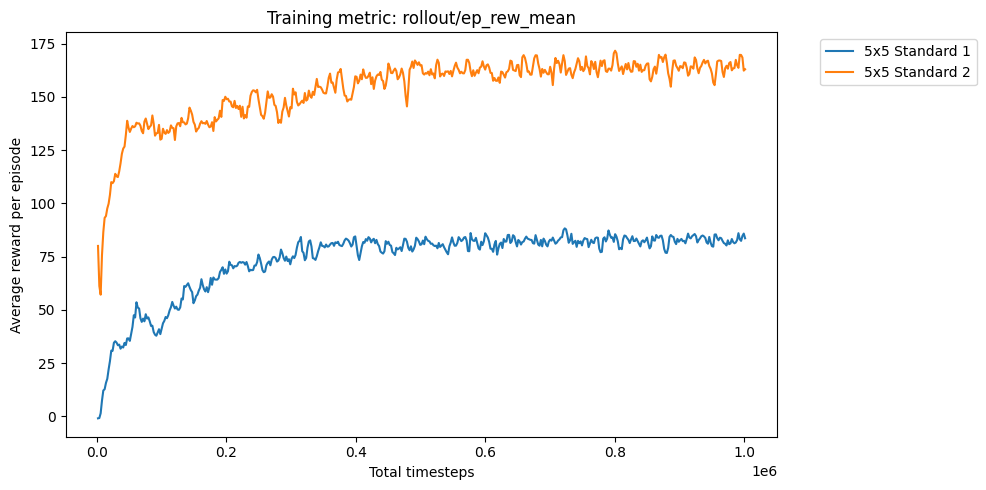

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(df_53200_train_1["time/total_timesteps"], df_53200_train_1["rollout/ep_rew_mean"], label='5x5 Standard 1')
plt.plot(df_53200_train_2["time/total_timesteps"], df_53200_train_2["rollout/ep_rew_mean"], label='5x5 Standard 2')

plt.title('Training metric: rollout/ep_rew_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

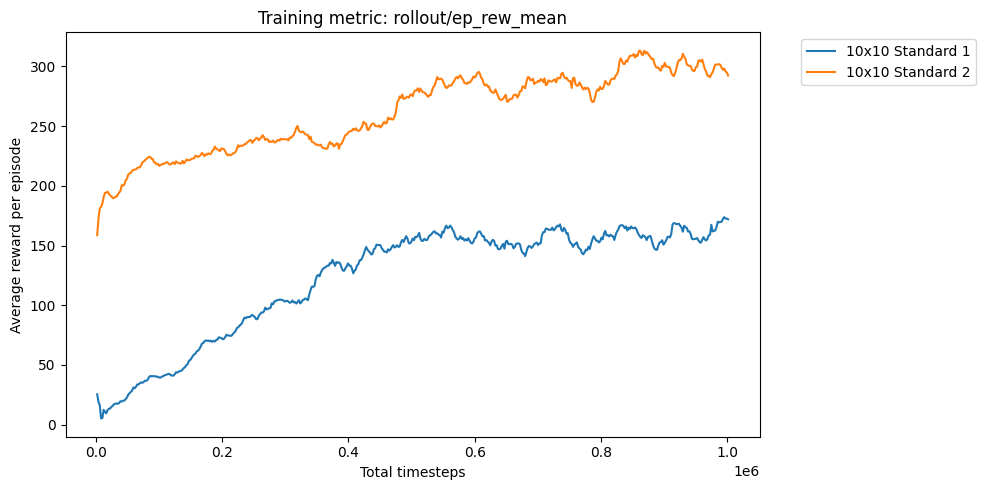

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(df_1012500_train_1["time/total_timesteps"], df_1012500_train_1["rollout/ep_rew_mean"], label='10x10 Standard 1')
plt.plot(df_1012500_train_2["time/total_timesteps"], df_1012500_train_2["rollout/ep_rew_mean"], label='10x10 Standard 2')

plt.title('Training metric: rollout/ep_rew_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

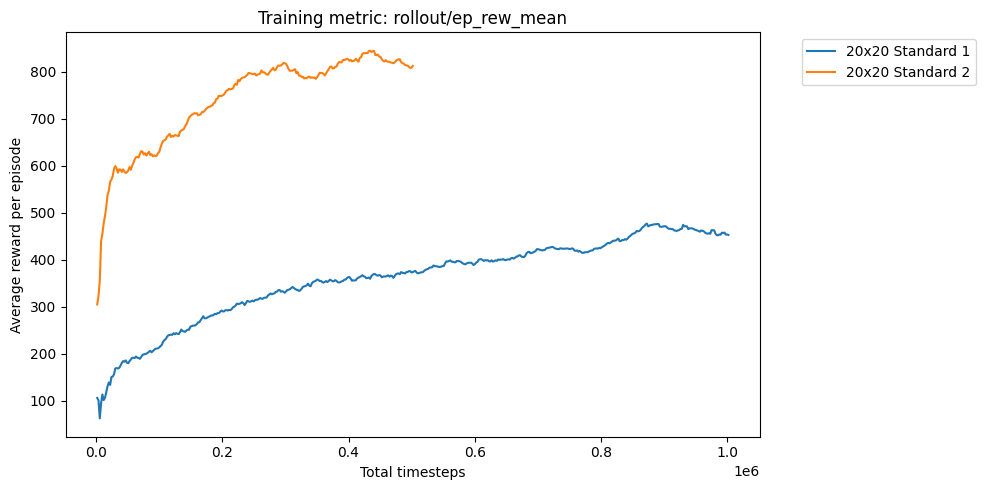

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(df_20481000_train_1["time/total_timesteps"], df_20481000_train_1["rollout/ep_rew_mean"], label='20x20 Standard 1')
plt.plot(df_20481000_train_2["time/total_timesteps"], df_20481000_train_2["rollout/ep_rew_mean"], label='20x20 Standard 2')

plt.title('Training metric: rollout/ep_rew_mean')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

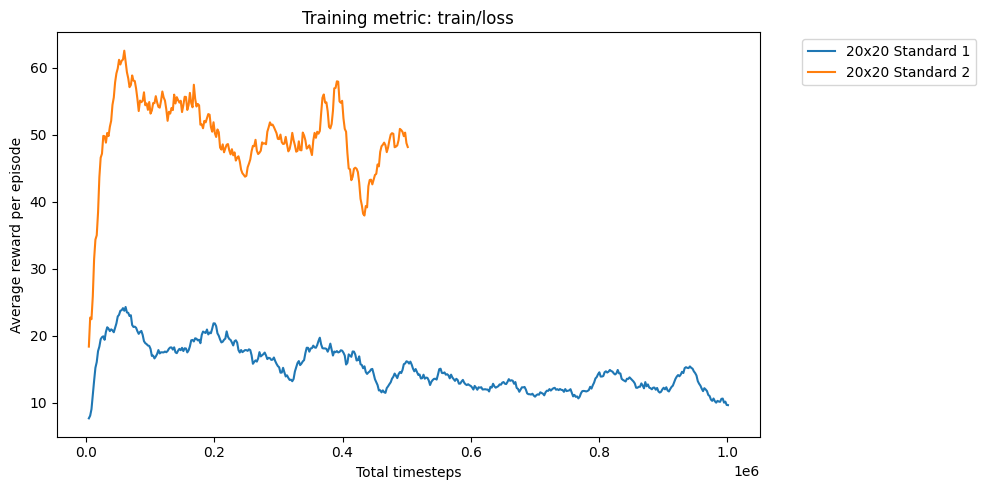

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(df_20481000_train_1["time/total_timesteps"], smooth_curve(df_20481000_train_1["train/loss"], window=20), label='20x20 Standard 1')
plt.plot(df_20481000_train_2["time/total_timesteps"], smooth_curve(df_20481000_train_2["train/loss"], window=20), label='20x20 Standard 2')

plt.title('Training metric: train/loss')

plt.xlabel('Total timesteps')
plt.ylabel('Average reward per episode')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Model Testing Results (Test Script)

The following table was generated by running 100 test episodes for the newly trained 5x5 and 10x10 models, capturing their average test reward, coverage, and pulling the final loss from the log files.

In [1]:

import os
import pandas as pd
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
import warnings
warnings.filterwarnings('ignore')

from gymnasium_env.grid_world_cpp_rshaping import GridWorldCPPRshapingEnv

try:
    gym.register(
        id="gymnasium_env/GridWorldCPPRshaping-v0",
        entry_point=GridWorldCPPRshapingEnv,
    )
except Exception:
    pass

models_to_test = [
    {
        "name": "ppo_cpp_rshaping_5_3_200_0.05_20260507_175453",
        "dim": 5,
        "obs": 3,
        "max_steps": 200,
        "label": "5x5 RShaping"
    },
    {
        "name": "ppo_cpp_rshaping_10_12_500_0.05_20260507_175454",
        "dim": 10,
        "obs": 12,
        "max_steps": 500,
        "label": "10x10 RShaping"
    }
]

results = []

print("Starting tests... This might take a moment to run 100 episodes per model.")

for m in models_to_test:
    model_path = f'data/{m["name"]}.zip'
    log_path = f'log/{m["name"]}/progress.csv'
    
    # 1. Extract Training Loss from Logs
    final_value_loss = np.nan
    final_policy_loss = np.nan
    final_ep_rew_mean = np.nan
    
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        if len(df_log) > 0:
            last_row = df_log.iloc[-1]
            if 'train/value_loss' in df_log.columns:
                final_value_loss = last_row['train/value_loss']
            if 'train/policy_gradient_loss' in df_log.columns:
                final_policy_loss = last_row['train/policy_gradient_loss']
            elif 'train/loss' in df_log.columns:
                final_policy_loss = last_row['train/loss']
            if 'rollout/ep_rew_mean' in df_log.columns:
                final_ep_rew_mean = last_row['rollout/ep_rew_mean']

    # 2. Run Test Episodes
    if os.path.exists(model_path):
        model = PPO.load(model_path)
        env = gym.make(
            "gymnasium_env/GridWorldCPPRshaping-v0",
            size=m["dim"],
            obs_quantity=m["obs"],
            max_steps=m["max_steps"],
            render_mode="rgb_array"
        )

        num_episodes = 100
        full_coverage_count = 0
        total_coverages = []
        total_steps_list = []
        total_rewards_list = []

        for i in range(num_episodes):
            (obs, info) = env.reset()
            done = False
            truncated = False
            steps = 0
            ep_reward = 0.0
            
            while not done and not truncated:
                action, _ = model.predict(obs, deterministic=False)
                obs, reward, done, truncated, info = env.step(action.item())
                ep_reward += reward
                steps += 1

            total_coverages.append(info['coverage'])
            total_steps_list.append(steps)
            total_rewards_list.append(ep_reward)

            if done and not truncated:
                full_coverage_count += 1
                
        results.append({
            "Model": m["label"],
            "Full Coverage Rate (%)": (full_coverage_count / num_episodes) * 100,
            "Avg Coverage (%)": np.mean(total_coverages) * 100,
            "Avg Steps": np.mean(total_steps_list),
            "Avg Test Reward": np.mean(total_rewards_list),
            "Train Avg Reward": final_ep_rew_mean,
            "Final Value Loss": final_value_loss,
            "Final Policy Loss": final_policy_loss
        })

df_results = pd.DataFrame(results)
display(df_results)


Starting tests... This might take a moment to run 100 episodes per model.


,Model,Full Coverage Rate (%),Avg Coverage (%),Avg Steps,Avg Test Reward,Train Avg Reward,Final Value Loss,Final Policy Loss
0,5x5 RShaping,94.0,99.727273,40.85,164.957773,162.924400,114.591171,-0.008148
1,10x10 RShaping,46.0,98.386364,400.14,314.970736,292.503759,23.382173,-0.010064


## 3x3 FOV vs 5x5 FOV Model Comparison

The following table compares the performance of the models trained with the original 3x3 Field of View versus the updated models with a 5x5 Field of View and Soft Reward Shaping. Each was tested over 100 episodes.

In [5]:

import os
import pandas as pd
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
import warnings
warnings.filterwarnings('ignore')

from gymnasium_env.grid_world_cpp import GridWorldCPPEnv
from gymnasium_env.grid_world_cpp_rshaping import GridWorldCPPRshapingEnv

try:
    gym.register(
        id="gymnasium_env/GridWorldCPP-v0",
        entry_point=GridWorldCPPEnv,
    )
except Exception:
    pass

try:
    gym.register(
        id="gymnasium_env/GridWorldCPPRshaping-v0",
        entry_point=GridWorldCPPRshapingEnv,
    )
except Exception:
    pass

models_to_test = [
    {
        "name": "ppo_cpp_5_3_200_0.05_20260505_214249",
        "env_id": "gymnasium_env/GridWorldCPP-v0",
        "dim": 5,
        "obs": 3,
        "max_steps": 200,
        "label": "5x5 (3x3 FOV, Original)"
    },
    {
        "name": "ppo_cpp_rshaping_5_3_200_0.05_20260507_175453",
        "env_id": "gymnasium_env/GridWorldCPPRshaping-v0",
        "dim": 5,
        "obs": 3,
        "max_steps": 200,
        "label": "5x5 (5x5 FOV, Shaped)"
    },
    {
        "name": "ppo_cpp_10_12_500_0.05_20260506_010440",
        "env_id": "gymnasium_env/GridWorldCPP-v0",
        "dim": 10,
        "obs": 12,
        "max_steps": 500,
        "label": "10x10 (3x3 FOV, Original)"
    },
    {
        "name": "ppo_cpp_rshaping_10_12_500_0.05_20260507_175454",
        "env_id": "gymnasium_env/GridWorldCPPRshaping-v0",
        "dim": 10,
        "obs": 12,
        "max_steps": 500,
        "label": "10x10 (5x5 FOV, Shaped)"
    },
    # {
    #     "name": "ppo_cpp_20_48_1000_0.05_20260506_114258",
    #     "env_id": "gymnasium_env/GridWorldCPP-v0",
    #     "dim": 20,
    #     "obs": 48,
    #     "max_steps": 1000,
    #     "label": "20x20 (3x3 FOV, Original)"
    # },
    # {
    #     "name": "ppo_cpp_rshaping_20_48_1000_0.05_20260507_161241",
    #     "env_id": "gymnasium_env/GridWorldCPPRshaping-v0",
    #     "dim": 20,
    #     "obs": 48,
    #     "max_steps": 1000,
    #     "label": "20x20 (5x5 FOV, Shaped)"
    # }
]

results = []

print("Starting comparison tests... This might take a few minutes (400 episodes total).")

for m in models_to_test:
    model_path = f'data/{m["name"]}.zip'
    log_path = f'log/{m["name"]}/progress.csv'
    
    # 1. Extract Training Loss from Logs
    final_value_loss = np.nan
    final_policy_loss = np.nan
    final_ep_rew_mean = np.nan
    
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        if len(df_log) > 0:
            last_row = df_log.iloc[-1]
            if 'train/value_loss' in df_log.columns:
                final_value_loss = last_row['train/value_loss']
            if 'train/policy_gradient_loss' in df_log.columns:
                final_policy_loss = last_row['train/policy_gradient_loss']
            elif 'train/loss' in df_log.columns:
                final_policy_loss = last_row['train/loss']
            if 'rollout/ep_rew_mean' in df_log.columns:
                final_ep_rew_mean = last_row['rollout/ep_rew_mean']

    # 2. Run Test Episodes
    if os.path.exists(model_path):
        model = PPO.load(model_path)
        env = gym.make(
            m["env_id"],
            size=m["dim"],
            obs_quantity=m["obs"],
            max_steps=m["max_steps"],
            render_mode="rgb_array"
        )

        num_episodes = 100
        full_coverage_count = 0
        total_coverages = []
        total_steps_list = []
        total_rewards_list = []

        for i in range(num_episodes):
            (obs, info) = env.reset()
            done = False
            truncated = False
            steps = 0
            ep_reward = 0.0
            
            while not done and not truncated:
                action, _ = model.predict(obs, deterministic=False)
                obs, reward, done, truncated, info = env.step(action.item())
                ep_reward += reward
                steps += 1

            total_coverages.append(info['coverage'])
            total_steps_list.append(steps)
            total_rewards_list.append(ep_reward)

            if done and not truncated:
                full_coverage_count += 1
                
        results.append({
            "Model": m["label"],
            "Full Coverage Rate (%)": (full_coverage_count / num_episodes) * 100,
            "Avg Coverage (%)": np.mean(total_coverages) * 100,
            "Avg Steps": np.mean(total_steps_list),
            "Avg Test Reward": np.mean(total_rewards_list),
            "Train Avg Reward": final_ep_rew_mean,
            "Final Value Loss": final_value_loss,
            "Final Policy Loss": final_policy_loss
        })

df_results = pd.DataFrame(results)
display(df_results)


Starting comparison tests... This might take a few minutes (400 episodes total).


,Model,Full Coverage Rate (%),Avg Coverage (%),Avg Steps,Avg Test Reward,Train Avg Reward,Final Value Loss,Final Policy Loss
0,"5x5 (3x3 FOV, Original)",98.0,99.909091,41.69,19.514000,17.315000,26.249403,-0.007978
1,"5x5 (5x5 FOV, Shaped)",97.0,99.818182,37.95,168.429455,162.924400,114.591171,-0.008148
2,"10x10 (3x3 FOV, Original)",74.0,99.556818,321.48,-14.195000,-23.011000,25.905523,-0.005293
3,"10x10 (5x5 FOV, Shaped)",38.0,96.840909,428.18,296.843905,292.503759,23.382173,-0.010064


## 20x20 Model Comparison

The following table compares the performance of the 20x20 model trained with the original 3x3 Field of View versus the properly evaluated 20x20 model with a 5x5 Field of View and Soft Reward Shaping. Testing over 100 episodes.

In [34]:

import os
import pandas as pd
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
import warnings
warnings.filterwarnings('ignore')

from gymnasium_env.grid_world_cpp import GridWorldCPPEnv
from gymnasium_env.grid_world_cpp_rshaping import GridWorldCPPRshapingEnv
from gymnasium_env.grid_world_cpp_distance import GridWorldCPPDistanceEnv

try:
    gym.register(
        id="gymnasium_env/GridWorldCPP-v0",
        entry_point=GridWorldCPPEnv,
    )
except Exception:
    pass

try:
    gym.register(
        id="gymnasium_env/GridWorldCPPRshaping-v0",
        entry_point=GridWorldCPPRshapingEnv,
    )
except Exception:
    pass

try:
    gym.register(
        id="gymnasium_env/GridWorldCPPRdistance-v0",
        entry_point=GridWorldCPPDistanceEnv,
    )
except Exception:
    pass

models_to_test = [
    {
        "name": "ppo_cpp_20_48_1000_0.05_20260506_114258",
        "env_id": "gymnasium_env/GridWorldCPP-v0",
        "dim": 20,
        "obs": 48,
        "max_steps": 1000,
        "label": "20x20 (3x3 FOV, Original)"
    },
    {
        "name": "ppo_cpp_rshaping_20_48_1000_0.05_20260508_105512",
        "env_id": "gymnasium_env/GridWorldCPPRshaping-v0",
        "dim": 20,
        "obs": 48,
        "max_steps": 1000,
        "label": "20x20 (5x5 FOV, Shaped)"
    },
    {
        "name": "ppo_cpp_distance_20_48_1000_0.05_20260508_131253",
        "env_id": "gymnasium_env/GridWorldCPPRdistance-v0",
        "dim": 20,
        "obs": 48,
        "max_steps": 1000,
        "label": "20x20 (5x5 FOV, Shaped, Distance)"
    },
    
]

results = []

print("Starting 20x20 comparison tests... This might take a few minutes (200 episodes total with max 1000 steps each).")

for m in models_to_test:
    model_path = f'data/{m["name"]}.zip'
    log_path = f'log/{m["name"]}/progress.csv'
    
    # 1. Extract Training Loss from Logs
    final_value_loss = np.nan
    final_policy_loss = np.nan
    final_ep_rew_mean = np.nan
    
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        if len(df_log) > 0:
            last_row = df_log.iloc[-1]
            if 'train/value_loss' in df_log.columns:
                final_value_loss = last_row['train/value_loss']
            if 'train/policy_gradient_loss' in df_log.columns:
                final_policy_loss = last_row['train/policy_gradient_loss']
            elif 'train/loss' in df_log.columns:
                final_policy_loss = last_row['train/loss']
            if 'rollout/ep_rew_mean' in df_log.columns:
                final_ep_rew_mean = last_row['rollout/ep_rew_mean']

    # 2. Run Test Episodes
    if os.path.exists(model_path):
        model = PPO.load(model_path)
        env = gym.make(
            m["env_id"],
            size=m["dim"],
            obs_quantity=m["obs"],
            max_steps=m["max_steps"],
            render_mode="rgb_array"
        )

        num_episodes = 100
        full_coverage_count = 0
        total_coverages = []
        total_steps_list = []
        total_rewards_list = []

        for i in range(num_episodes):
            (obs, info) = env.reset()
            done = False
            truncated = False
            steps = 0
            ep_reward = 0.0
            
            while not done and not truncated:
                action, _ = model.predict(obs, deterministic=False)
                obs, reward, done, truncated, info = env.step(action.item())
                ep_reward += reward
                steps += 1

            total_coverages.append(info['coverage'])
            total_steps_list.append(steps)
            total_rewards_list.append(ep_reward)

            if done and not truncated:
                full_coverage_count += 1
                
        results.append({
            "Model": m["label"],
            "Full Coverage Rate (%)": (full_coverage_count / num_episodes) * 100,
            "Avg Coverage (%)": np.mean(total_coverages) * 100,
            "Avg Steps": np.mean(total_steps_list),
            "Avg Test Reward": np.mean(total_rewards_list),
            "Train Avg Reward": final_ep_rew_mean,
            "Final Value Loss": final_value_loss,
            "Final Policy Loss": final_policy_loss
        })

df_results = pd.DataFrame(results)
display(df_results)


Starting 20x20 comparison tests... This might take a few minutes (200 episodes total with max 1000 steps each).


,Model,Full Coverage Rate (%),Avg Coverage (%),Avg Steps,Avg Test Reward,Train Avg Reward,Final Value Loss,Final Policy Loss
0,"20x20 (3x3 FOV, Original)",0.0,92.840909,1000.0,10.828000,9.304000,8.935337,-0.007901
1,"20x20 (5x5 FOV, Shaped)",0.0,78.332386,1000.0,725.570989,812.069551,97.849141,-0.013011
2,"20x20 (5x5 FOV, Shaped, Distance)",0.0,86.914773,1000.0,872.555949,851.785443,90.045825,-0.010232
